In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Ignore warning messages
warnings.filterwarnings("ignore")

# Display all dataset columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Upload the dataset from your computer

from google.colab import files

uploaded = files.upload()

Saving adult.csv to adult.csv


In [ ]:
# Display the uploaded filename

print(uploaded.keys())

dict_keys(['adult.csv'])


In [ ]:
# Load the Adult Income dataset

df = pd.read_csv("adult.csv")

# Display dataset size
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# Display the first five rows
df.head()

Dataset loaded successfully!
Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
# Display dataset information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
# Display statistical summary of numerical columns

df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
# Count "?" values in each column

question_mark_count = (df == "?").sum()

# Display only columns containing "?"
question_mark_count[question_mark_count > 0]

,0
workclass,2799
occupation,2809
native-country,857


In [ ]:
# Replace "?" with actual missing values

df.replace("?", np.nan, inplace=True)

# Display missing values in each column

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
workclass,2799
occupation,2809
native-country,857


In [ ]:
# Fill missing categorical values with the most frequent value (mode)

columns_with_missing = ["workclass", "occupation", "native-country"]

for column in columns_with_missing:
    df[column] = df[column].fillna(df[column].mode()[0])

# Check the total number of missing values

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
# Count duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 53


In [ ]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

# Reset the index after removing duplicates

df.reset_index(drop=True, inplace=True)

# Verify that no duplicate rows remain

print("Number of duplicate rows:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Dataset shape after removing duplicates: (48789, 15)


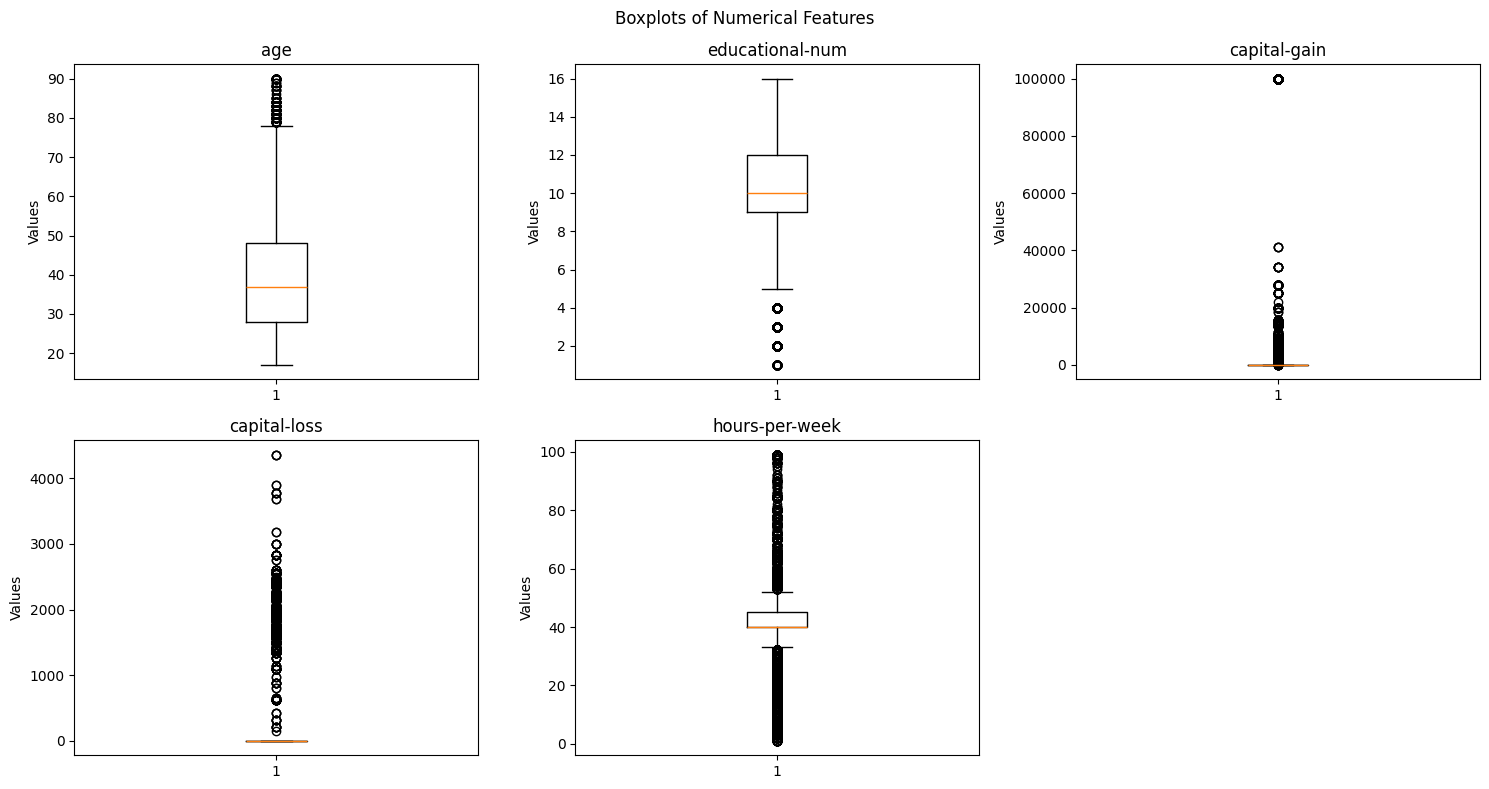

In [ ]:
# Select numerical columns for outlier analysis

outlier_columns = [
    "age",
    "educational-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# Create boxplots for numerical features

plt.figure(figsize=(15, 8))

for i, column in enumerate(outlier_columns, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df[column])
    plt.title(column)
    plt.ylabel("Values")

plt.suptitle("Boxplots of Numerical Features")
plt.tight_layout()
plt.show()

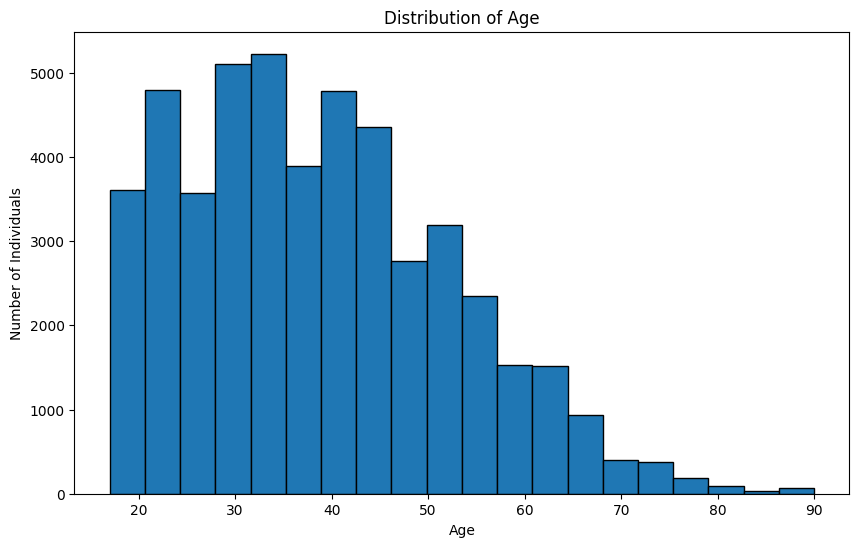

In [ ]:
# Visualization 1: Distribution of age

plt.figure(figsize=(10, 6))

plt.hist(
    df["age"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Individuals")

plt.show()

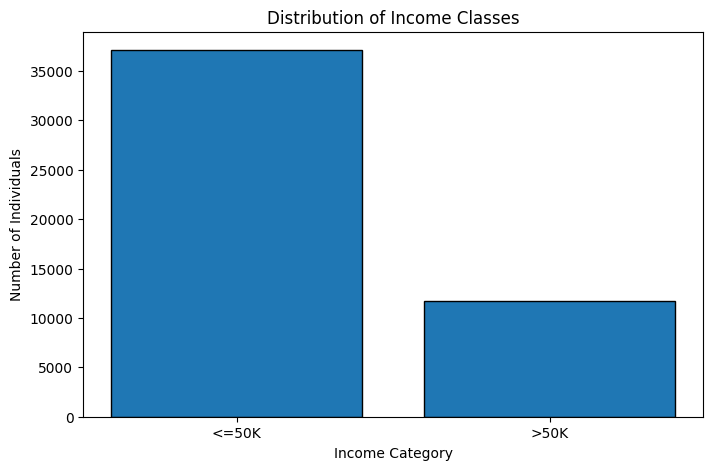

Income counts:
income
<=50K    37108
>50K     11681
Name: count, dtype: int64

Income percentages:
income
<=50K    76.06
>50K     23.94
Name: proportion, dtype: float64


In [ ]:
# Visualization 2: Distribution of income categories

income_counts = df["income"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    income_counts.index,
    income_counts.values,
    edgecolor="black"
)

plt.title("Distribution of Income Classes")
plt.xlabel("Income Category")
plt.ylabel("Number of Individuals")

plt.show()

# Display income counts and percentages

print("Income counts:")
print(income_counts)

print("\nIncome percentages:")
print((df["income"].value_counts(normalize=True) * 100).round(2))

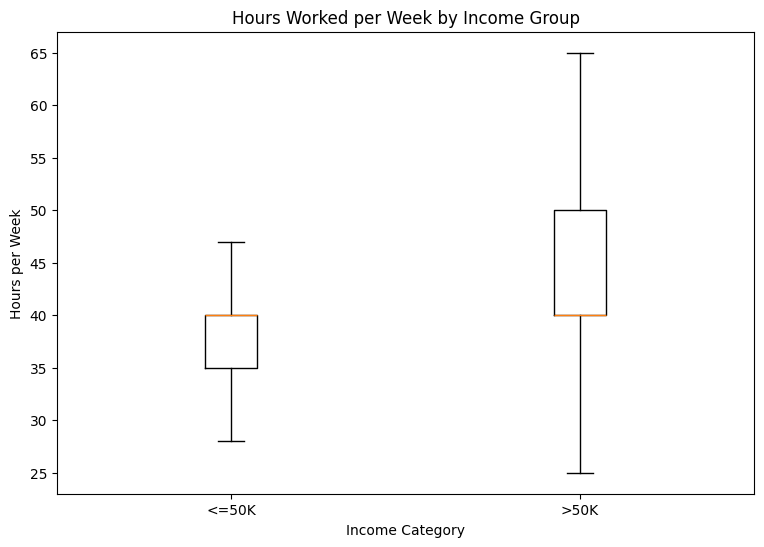

In [ ]:
income_groups = [
    df[df["income"] == "<=50K"]["hours-per-week"],
    df[df["income"] == ">50K"]["hours-per-week"]
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    income_groups,
    labels=["<=50K", ">50K"],
    showfliers=False
)

plt.title("Hours Worked per Week by Income Group")
plt.xlabel("Income Category")
plt.ylabel("Hours per Week")

plt.show()

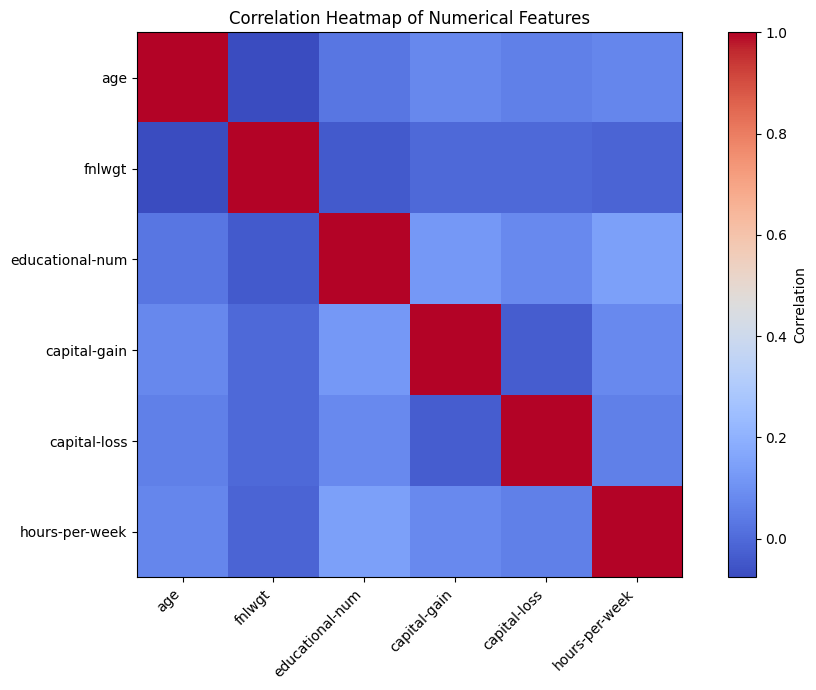

In [ ]:
# Visualization 4: Correlation heatmap of numerical features

numerical_columns = [
    "age",
    "fnlwgt",
    "educational-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# Calculate the correlation matrix

correlation_matrix = df[numerical_columns].corr()

# Create the heatmap

plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numerical_columns)),
    numerical_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numerical_columns)),
    numerical_columns
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [ ]:
# Feature Engineering

# Create age groups

age_bins = [16, 25, 35, 45, 55, 65, 100]

age_labels = [
    "17-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df["age-group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)


# Create work-hours categories

def categorize_work_hours(hours):

    if hours < 35:
        return "Part-time"

    elif hours <= 40:
        return "Standard"

    elif hours <= 60:
        return "Overtime"

    else:
        return "Heavy Overtime"


df["work-hours-category"] = df["hours-per-week"].apply(
    categorize_work_hours
)


# Calculate net capital

df["net-capital"] = (
    df["capital-gain"] - df["capital-loss"]
)


# Display the new features

df[
    [
        "age",
        "age-group",
        "hours-per-week",
        "work-hours-category",
        "capital-gain",
        "capital-loss",
        "net-capital"
    ]
].head(10)

,age,age-group,hours-per-week,work-hours-category,capital-gain,capital-loss,net-capital
0,25,17-25,40,Standard,0,0,0
1,38,36-45,50,Overtime,0,0,0
2,28,26-35,40,Standard,0,0,0
3,44,36-45,40,Standard,7688,0,7688
4,18,17-25,30,Part-time,0,0,0
5,34,26-35,30,Part-time,0,0,0
6,29,26-35,40,Standard,0,0,0
7,63,56-65,32,Part-time,3103,0,3103
8,24,17-25,40,Standard,0,0,0
9,55,46-55,10,Part-time,0,0,0


In [ ]:
# Final validation of the cleaned dataset

print("Final dataset shape:", df.shape)

print(
    "Total missing values:",
    df.isnull().sum().sum()
)

print(
    "Total duplicate rows:",
    df.duplicated().sum()
)

print("\nNew engineered features:")

print(
    df[
        [
            "age-group",
            "work-hours-category",
            "net-capital"
        ]
    ].head()
)

Final dataset shape: (48789, 18)
Total missing values: 0
Total duplicate rows: 0

New engineered features:
  age-group work-hours-category  net-capital
0     17-25            Standard            0
1     36-45            Overtime            0
2     26-35            Standard            0
3     36-45            Standard         7688
4     17-25           Part-time            0


# Key Insights

# 1. Most individuals in the dataset are between approximately
#    25 and 50 years old, while fewer individuals are above age 65.

# 2. The income classes are imbalanced. Approximately 76% of
#    individuals earn <=50K, while about 24% earn >50K.

# 3. Individuals earning >50K generally work more hours per week
#    than individuals earning <=50K.

# 4. Numerical features have mostly weak linear correlations.
#    Educational level, age, capital gain, and working hours may
#    still be useful predictors of income.

# 5. Capital gain and capital loss contain many zero values and
#    a small number of large values. These values were retained
#    because they may represent valid financial information.

In [ ]:
df.to_csv("adult_income_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Final dataset shape:", df.shape)

Cleaned dataset saved successfully!
Final dataset shape: (48789, 18)


In [ ]:
from google.colab import files

files.download("adult_income_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>